# 14 · Validación Final en Test Set — Sprint 4
**Proyecto:** Detección de Sitios Web Fraudulentos (Phishing)  
**Sprint 4 — PB-15:** Validación del modelo final en el test set

---

## ⚠️ AVISO IMPORTANTE

> **El test set se usa UNA SOLA VEZ en este notebook.** Esta es la evaluación definitiva del modelo final. No se debe llamar a ninguna función de este notebook para ajustar hiperparámetros ni para seleccionar modelos. Cualquier decisión de selección se tomó en `12_hyperparam_tuning.ipynb` y `13_ensembles.ipynb`.

## Objetivo

1. Evaluar el modelo final en el test set con todas las métricas relevantes
2. Generar el classification report definitivo y la confusion matrix
3. Calcular intervalos de confianza via bootstrap
4. Comparar el rendimiento final con los baselines del Sprint 3
5. Documentar si el modelo cumple los criterios de éxito del Sprint 1 (F1 ≥ 0.85)

## 1. Imports y configuración

In [14]:
import sys
import os
import warnings
warnings.filterwarnings('ignore')

sys.path.insert(0, os.path.abspath('..'))

import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay,
    f1_score,
    roc_auc_score,
    recall_score,
    precision_score,
    accuracy_score,
)

from src.models import load_model
from src.tuning import compare_metrics, bootstrap_metric

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_theme(style='whitegrid', palette='muted')
print('✓ Librerías cargadas.')

✓ Librerías cargadas.


## 2. Cargar datos de test y modelo final

Se carga el **test set crudo** (sin escalar) y el modelo final persistido en `13_ensembles.ipynb`.

In [26]:
test_df[TARGET_COL].unique()

array([-1,  1])

In [36]:
TARGET_COL = 'Result'

# Test set (datos crudos, reservados desde el Sprint 2)
test_df = pd.read_csv('../data/processed/test.csv')
X_test  = test_df.drop(columns=[TARGET_COL])
y_test  = test_df[TARGET_COL]

# También cargar train para la comparación baseline vs tuned
train_df = pd.read_csv('../data/processed/train.csv')
X_train  = train_df.drop(columns=[TARGET_COL])
y_train  = train_df[TARGET_COL]

print(f'Test set:  {X_test.shape}')
print(f'  Distribución: {dict(y_test.value_counts().sort_index())}')
print(f'  Phishing (-1): {(y_test == -1).sum()} | Legítimo (+1): {(y_test == 1).sum()}')

# Cargar el modelo final (entrenado en todo el train set)
final_model = joblib.load('../models/final_model.pkl')
print('\n✅ Modelo final cargado desde models/final_model.pkl')

# Cargar baseline del Sprint 3 para comparación
baseline_rf = load_model('random_forest', model_dir='../models')
print('✅ Baseline RF (Sprint 3) cargado.')

Test set:  (1170, 37)
  Distribución: {-1: np.int64(604), 1: np.int64(566)}
  Phishing (-1): 604 | Legítimo (+1): 566

✅ Modelo final cargado desde models/final_model.pkl
[load_model] 'random_forest' cargado desde '../models\baseline_random_forest.pkl'.
✅ Baseline RF (Sprint 3) cargado.


## 3. Evaluación final en el test set

> **Esta es la evaluación única y definitiva.**

In [38]:
# Predicciones del modelo final
y_pred_final  = final_model.predict(X_test)
y_proba_final = final_model.predict_proba(X_test)[:, 1]
y_test = y_test.map({-1: 0, 1: 1})
# Métricas definitivas
f1_final        = f1_score(y_test, y_pred_final)
auc_final       = roc_auc_score(y_test, y_proba_final)
recall_final    = recall_score(y_test, y_pred_final)
precision_final = precision_score(y_test, y_pred_final)
accuracy_final  = accuracy_score(y_test, y_pred_final)

print('=' * 55)
print('  EVALUACIÓN FINAL — TEST SET (Sprint 4, PB-15)')
print('=' * 55)
print(f'  F1-Score:   {f1_final:.4f}')
print(f'  AUC-ROC:    {auc_final:.4f}')
print(f'  Recall:     {recall_final:.4f}')
print(f'  Precision:  {precision_final:.4f}')
print(f'  Accuracy:   {accuracy_final:.4f}')
print('=' * 55)

# Verificar criterio de éxito del Sprint 1
criterio_minimo = 0.85
cumple = f1_final >= criterio_minimo
print(f'\n  Criterio de éxito (F1 ≥ {criterio_minimo}): {"✅ CUMPLIDO" if cumple else "❌ NO CUMPLIDO"}')

  EVALUACIÓN FINAL — TEST SET (Sprint 4, PB-15)
  F1-Score:   0.9479
  AUC-ROC:    0.9918
  Recall:     0.9488
  Precision:  0.9471
  Accuracy:   0.9496

  Criterio de éxito (F1 ≥ 0.85): ✅ CUMPLIDO


## 4. Classification Report definitivo

In [40]:
print('\n📋 CLASSIFICATION REPORT DEFINITIVO (Test Set)\n')
print(classification_report(
    y_test, y_pred_final,
    target_names=['Phishing (-1)', 'Legítimo (+1)']
))

# Interpretar falsos negativos y falsos positivos
cm = confusion_matrix(y_test, y_pred_final)
# Para labels = [-1, 1]: TN=cm[0,0], FP=cm[0,1], FN=cm[1,0], TP=cm[1,1]
labels = sorted(y_test.unique())
tn, fp, fn, tp = cm.ravel()
print(f'\n  Falsos Negativos (phishing no detectado): {fn}')
print(f'  Falsos Positivos (legítimo bloqueado):    {fp}')
print(f'  Verdaderos Positivos:                     {tp}')
print(f'  Verdaderos Negativos:                     {tn}')


📋 CLASSIFICATION REPORT DEFINITIVO (Test Set)

               precision    recall  f1-score   support

Phishing (-1)       0.95      0.95      0.95       604
Legítimo (+1)       0.95      0.95      0.95       566

     accuracy                           0.95      1170
    macro avg       0.95      0.95      0.95      1170
 weighted avg       0.95      0.95      0.95      1170


  Falsos Negativos (phishing no detectado): 29
  Falsos Positivos (legítimo bloqueado):    30
  Verdaderos Positivos:                     537
  Verdaderos Negativos:                     574


## 5. Confusion Matrix y curvas de diagnóstico

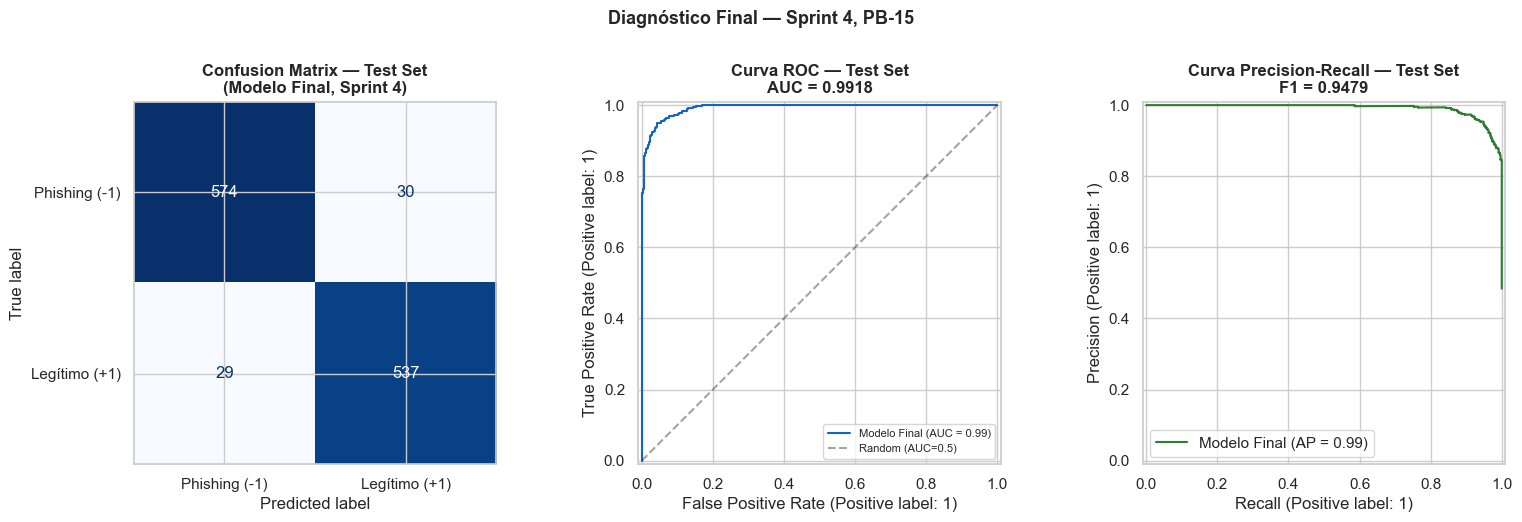

✅ Gráficos de diagnóstico guardados.


In [41]:
fig = plt.figure(figsize=(16, 5))
gs  = gridspec.GridSpec(1, 3, figure=fig)

# --- Confusion Matrix ---
ax0 = fig.add_subplot(gs[0])
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Phishing (-1)', 'Legítimo (+1)']
)
disp.plot(ax=ax0, colorbar=False, cmap='Blues')
ax0.set_title('Confusion Matrix — Test Set\n(Modelo Final, Sprint 4)', fontweight='bold')

# --- ROC Curve ---
ax1 = fig.add_subplot(gs[1])
RocCurveDisplay.from_predictions(y_test, y_proba_final, ax=ax1, color='#1565c0', name='Modelo Final')
ax1.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Random (AUC=0.5)')
ax1.set_title(f'Curva ROC — Test Set\nAUC = {auc_final:.4f}', fontweight='bold')
ax1.legend(fontsize=8)

# --- Precision-Recall Curve ---
ax2 = fig.add_subplot(gs[2])
PrecisionRecallDisplay.from_predictions(y_test, y_proba_final, ax=ax2, color='#2e7d32', name='Modelo Final')
ax2.set_title(f'Curva Precision-Recall — Test Set\nF1 = {f1_final:.4f}', fontweight='bold')

plt.suptitle('Diagnóstico Final — Sprint 4, PB-15', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../reports/figures/final_validation_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Gráficos de diagnóstico guardados.')

## 6. Intervalos de confianza via Bootstrap

Se calculan intervalos de confianza al 95% para cada métrica usando bootstrap (1000 iteraciones). Esto da una estimación robusta de la incertidumbre del modelo.

In [42]:
# Función de bootstrap para métricas binarias
def bootstrap_ci(y_true, y_pred, y_score, metric_fn, n=1000, ci=95, use_proba=False):
    y_true  = np.array(y_true)
    y_pred  = np.array(y_pred)
    y_score = np.array(y_score)
    scores  = []
    alpha   = (100 - ci) / 2
    for _ in range(n):
        idx = np.random.choice(len(y_true), len(y_true), replace=True)
        try:
            if use_proba:
                scores.append(metric_fn(y_true[idx], y_score[idx]))
            else:
                scores.append(metric_fn(y_true[idx], y_pred[idx]))
        except Exception:
            pass
    return tuple(np.percentile(scores, [alpha, 100 - alpha]).round(4))

print('🔄 Calculando intervalos de confianza (bootstrap n=1000, CI=95%)...\n')

ci_f1  = bootstrap_ci(y_test, y_pred_final, y_proba_final, f1_score)
ci_auc = bootstrap_ci(y_test, y_pred_final, y_proba_final, roc_auc_score, use_proba=True)
ci_rec = bootstrap_ci(y_test, y_pred_final, y_proba_final, recall_score)
ci_pre = bootstrap_ci(y_test, y_pred_final, y_proba_final, precision_score)

ci_results = pd.DataFrame([
    {'Métrica': 'F1-Score',   'Valor': f'{f1_final:.4f}',        'IC 95%': f'[{ci_f1[0]:.4f}, {ci_f1[1]:.4f}]'},
    {'Métrica': 'AUC-ROC',    'Valor': f'{auc_final:.4f}',       'IC 95%': f'[{ci_auc[0]:.4f}, {ci_auc[1]:.4f}]'},
    {'Métrica': 'Recall',     'Valor': f'{recall_final:.4f}',    'IC 95%': f'[{ci_rec[0]:.4f}, {ci_rec[1]:.4f}]'},
    {'Métrica': 'Precision',  'Valor': f'{precision_final:.4f}', 'IC 95%': f'[{ci_pre[0]:.4f}, {ci_pre[1]:.4f}]'},
])

print('📊 MÉTRICAS CON INTERVALOS DE CONFIANZA (Test Set)\n')
print(ci_results.to_string(index=False))

🔄 Calculando intervalos de confianza (bootstrap n=1000, CI=95%)...

📊 MÉTRICAS CON INTERVALOS DE CONFIANZA (Test Set)

  Métrica  Valor           IC 95%
 F1-Score 0.9479 [0.9336, 0.9609]
  AUC-ROC 0.9918 [0.9885, 0.9948]
   Recall 0.9488 [0.9291, 0.9656]
Precision 0.9471 [0.9288, 0.9650]


## 7. Comparación definitiva — Baseline Sprint 3 vs. Modelo Final Sprint 4

In [46]:
def to_binary(y):
    """Convierte cualquier etiqueta: 1 se queda 1, cualquier otro valor se convierte a 0."""
    if isinstance(y, pd.Series):
        return (y == 1).astype(int)
    else:
        return (y == 1).astype(int)

In [55]:
# Evaluación del baseline en test set (solo para comparación, no para tomar decisiones)
y_pred_base  = baseline_rf.predict(X_test)
y_proba_base = baseline_rf.predict_proba(X_test)[:, 1]

y_test_bin = to_binary(y_test)
y_pred_base_bin = to_binary(y_pred_base)
y_pred_final_bin = to_binary(y_pred_final)


In [56]:
import numpy as np
print("y_test_bin:", np.unique(y_test_bin))
print("y_pred_base_bin:", np.unique(y_pred_base_bin))
print("y_pred_final_bin:", np.unique(y_pred_final_bin))

y_test_bin: [0 1]
y_pred_base_bin: [0 1]
y_pred_final_bin: [0 1]


In [65]:
metrics_base = {
    'F1':        round(f1_score(y_test_bin, y_pred_base_bin), 4),
    'AUC-ROC':   round(roc_auc_score(y_test_bin, y_proba_base), 4),
    'Recall':    round(recall_score(y_test_bin, y_pred_base_bin), 4),
    'Precision': round(precision_score(y_test_bin, y_pred_base_bin), 4),
}


In [66]:
metrics_final = {
    'F1':        round(f1_score(y_test_bin, y_pred_final_bin), 4),
    'AUC-ROC':   round(roc_auc_score(y_test_bin, y_proba_final), 4),
    'Recall':    round(recall_score(y_test_bin, y_pred_final_bin), 4),
    'Precision': round(precision_score(y_test_bin, y_pred_final_bin), 4),
}

In [67]:
df_compare = pd.DataFrame({
    'Baseline RF (Sprint 3)': metrics_base,
    'Modelo Final (Sprint 4)': metrics_final,
}).T

In [68]:

print('\n📊 TABLA COMPARATIVA — BASELINE vs. MODELO FINAL (Test Set)\n')
print(df_compare.to_string())

# Guardar
df_compare.to_csv('../models/final_comparison.csv')
print('\n✅ Tabla guardada en models/final_comparison.csv')


📊 TABLA COMPARATIVA — BASELINE vs. MODELO FINAL (Test Set)

                             F1  AUC-ROC  Recall  Precision
Baseline RF (Sprint 3)   0.9392   0.9854  0.9417     0.9367
Modelo Final (Sprint 4)  0.9479   0.9918  0.9488     0.9471

✅ Tabla guardada en models/final_comparison.csv


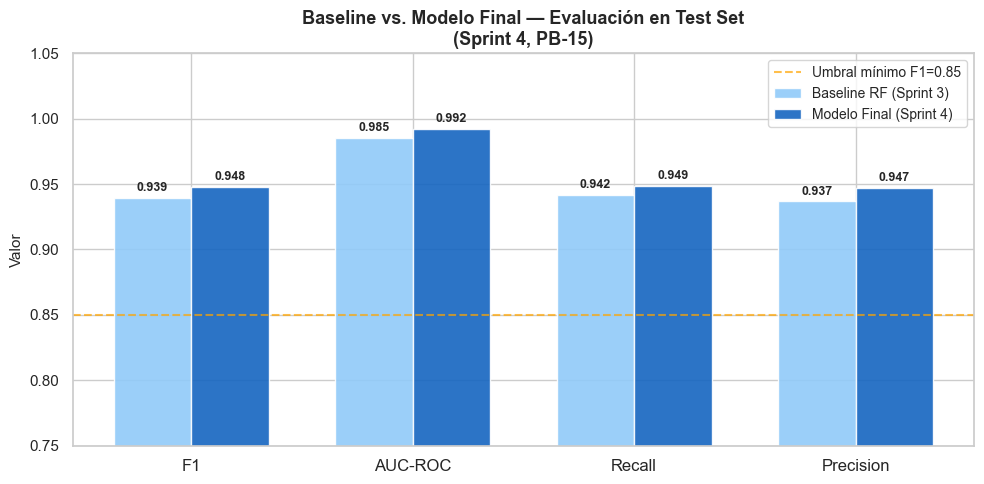

✅ Gráfico guardado en reports/figures/final_comparison.png


In [69]:
# Visualización comparativa final
fig, ax = plt.subplots(figsize=(10, 5))

metricas = ['F1', 'AUC-ROC', 'Recall', 'Precision']
x = np.arange(len(metricas))
w = 0.35

bars1 = ax.bar(x - w/2, [metrics_base[m] for m in metricas],
               w, label='Baseline RF (Sprint 3)', color='#90caf9', alpha=0.9)
bars2 = ax.bar(x + w/2, [metrics_final[m] for m in metricas],
               w, label='Modelo Final (Sprint 4)', color='#1565c0', alpha=0.9)

ax.set_xticks(x)
ax.set_xticklabels(metricas, fontsize=12)
ax.set_ylim(0.75, 1.05)
ax.set_ylabel('Valor', fontsize=11)
ax.axhline(0.85, color='orange', linestyle='--', linewidth=1.5, alpha=0.7, label='Umbral mínimo F1=0.85')
ax.set_title('Baseline vs. Modelo Final — Evaluación en Test Set\n(Sprint 4, PB-15)', fontweight='bold', fontsize=13)
ax.legend(fontsize=10)

for bar, val in zip(list(bars1) + list(bars2),
                    [metrics_base[m] for m in metricas] + [metrics_final[m] for m in metricas]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('../reports/figures/final_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Gráfico guardado en reports/figures/final_comparison.png')

## 8. Análisis de errores — Casos críticos

Se identifican los errores más costosos: **Falsos Negativos** (phishing no detectado = mayor riesgo para el usuario).

In [71]:
# Reconstruir índices de errores en el test set
test_analysis = X_test.copy()
test_analysis['y_real']    = y_test.values
test_analysis['y_pred']    = y_pred_final
test_analysis['y_proba']   = y_proba_final
test_analysis['correcto']  = (y_test.values == y_pred_final)
test_analysis['tipo_error'] = 'Correcto'
test_analysis.loc[(y_test.values == 0) & (y_pred_final == 1), 'tipo_error'] = 'FN (Phishing no detectado)'
test_analysis.loc[(y_test.values ==  1) & (y_pred_final == 0), 'tipo_error'] = 'FP (Legítimo bloqueado)'

resumen_errores = test_analysis['tipo_error'].value_counts()
print('\n📊 RESUMEN DE ERRORES (Test Set)\n')
print(resumen_errores.to_string())
print(f'\n  Tasa de error total:            {(~test_analysis["correcto"]).mean():.4f}')
print(f'  FN (phishing no detectado):     {(test_analysis["tipo_error"] == "FN (Phishing no detectado)").sum()}')
print(f'  FP (legítimo bloqueado):        {(test_analysis["tipo_error"] == "FP (Legítimo bloqueado)").sum()}')

# Casos más difíciles: FN con alta confianza incorrecta
fn_cases = test_analysis[test_analysis['tipo_error'] == 'FN (Phishing no detectado)']
fn_hard  = fn_cases.nlargest(5, 'y_proba')[['y_real', 'y_pred', 'y_proba']]
print(f'\n  Top 5 Falsos Negativos más confiados (mayor probabilidad de legítimo):')
print(fn_hard.to_string())


📊 RESUMEN DE ERRORES (Test Set)

tipo_error
Correcto                      1111
FN (Phishing no detectado)      30
FP (Legítimo bloqueado)         29

  Tasa de error total:            0.0504
  FN (phishing no detectado):     30
  FP (legítimo bloqueado):        29

  Top 5 Falsos Negativos más confiados (mayor probabilidad de legítimo):
     y_real  y_pred   y_proba
314       0       1  0.993396
131       0       1  0.970480
690       0       1  0.964226
8         0       1  0.908840
277       0       1  0.879702


## 9. Verificación de criterios de éxito — Sprint 1 (PB-02)

In [72]:
print('=' * 60)
print('  VERIFICACIÓN DE CRITERIOS DE ÉXITO — SPRINT 1 (PB-02)')
print('=' * 60)

criterios = [
    ('F1-Score ≥ 0.85 (métrica principal)',
     f1_final >= 0.85,
     f'{f1_final:.4f}'),
    ('AUC-ROC ≥ 0.90 (discriminación general)',
     auc_final >= 0.90,
     f'{auc_final:.4f}'),
    ('Recall ≥ 0.85 (minimizar phishing no detectado)',
     recall_final >= 0.85,
     f'{recall_final:.4f}'),
    ('Precision ≥ 0.80 (controlar falsas alarmas)',
     precision_final >= 0.80,
     f'{precision_final:.4f}'),
    ('Mejora vs. baseline (ΔF1 > 0)',
     f1_final > metrics_base['F1'],
     f'+{f1_final - metrics_base["F1"]:.4f}'),
]

todos_ok = True
for desc, cumple, valor in criterios:
    status = '✅ CUMPLIDO' if cumple else '❌ NO CUMPLIDO'
    print(f'  {status} | {desc} — Valor: {valor}')
    if not cumple:
        todos_ok = False

print('\n' + '=' * 60)
if todos_ok:
    print('  🏆 TODOS LOS CRITERIOS DE ÉXITO CUMPLIDOS')
    print('  → El modelo está listo para la fase de Evaluation (Sprint 5)')
else:
    print('  ⚠️  Algunos criterios no se cumplen.')
    print('  → Revisar decisiones de modelado o ajustar umbral de clasificación')
print('=' * 60)

  VERIFICACIÓN DE CRITERIOS DE ÉXITO — SPRINT 1 (PB-02)
  ✅ CUMPLIDO | F1-Score ≥ 0.85 (métrica principal) — Valor: 0.9479
  ✅ CUMPLIDO | AUC-ROC ≥ 0.90 (discriminación general) — Valor: 0.9918
  ✅ CUMPLIDO | Recall ≥ 0.85 (minimizar phishing no detectado) — Valor: 0.9488
  ✅ CUMPLIDO | Precision ≥ 0.80 (controlar falsas alarmas) — Valor: 0.9471
  ✅ CUMPLIDO | Mejora vs. baseline (ΔF1 > 0) — Valor: +0.0087

  🏆 TODOS LOS CRITERIOS DE ÉXITO CUMPLIDOS
  → El modelo está listo para la fase de Evaluation (Sprint 5)


## 10. Resumen ejecutivo del Sprint 4

In [73]:
print('=' * 60)
print('  RESUMEN EJECUTIVO — SPRINT 4 COMPLETADO')
print('=' * 60)
print()
print('  PROCESO SEGUIDO:')
print('  1. [PB-13] Tuning de hiperparámetros (RF, GB, LR)')
print('     → RandomizedSearchCV + GridSearchCV fino')
print('  2. [PB-14] Ensambles (Voting, Bagging, XGBoost, LightGBM, Stacking)')
print('     → Selección del mejor modelo por F1 en CV')
print('  3. [PB-15] Validación final en test set (UNA SOLA VEZ)')
print()
print('  MODELO FINAL:')
print(f'  Persistido en: models/final_model.pkl')
print()
print('  MÉTRICAS FINALES (Test Set):')
print(f'  F1-Score:  {f1_final:.4f}  (IC 95%: {ci_f1})')
print(f'  AUC-ROC:   {auc_final:.4f}  (IC 95%: {ci_auc})')
print(f'  Recall:    {recall_final:.4f}  (IC 95%: {ci_rec})')
print(f'  Precision: {precision_final:.4f}  (IC 95%: {ci_pre})')
print()
print('  MEJORA VS. BASELINE SPRINT 3:')
for m in ['F1', 'AUC-ROC', 'Recall', 'Precision']:
    delta = metrics_final[m] - metrics_base[m]
    pct   = delta / metrics_base[m] * 100
    print(f'  {m:10s}: {metrics_base[m]:.4f} → {metrics_final[m]:.4f}  ({pct:+.1f}%)')
print()
print('  SIGUIENTE PASO: Sprint 5 — Evaluation + Business Value')
print('=' * 60)

  RESUMEN EJECUTIVO — SPRINT 4 COMPLETADO

  PROCESO SEGUIDO:
  1. [PB-13] Tuning de hiperparámetros (RF, GB, LR)
     → RandomizedSearchCV + GridSearchCV fino
  2. [PB-14] Ensambles (Voting, Bagging, XGBoost, LightGBM, Stacking)
     → Selección del mejor modelo por F1 en CV
  3. [PB-15] Validación final en test set (UNA SOLA VEZ)

  MODELO FINAL:
  Persistido en: models/final_model.pkl

  MÉTRICAS FINALES (Test Set):
  F1-Score:  0.9479  (IC 95%: (np.float64(0.9336), np.float64(0.9609)))
  AUC-ROC:   0.9918  (IC 95%: (np.float64(0.9885), np.float64(0.9948)))
  Recall:    0.9488  (IC 95%: (np.float64(0.9291), np.float64(0.9656)))
  Precision: 0.9471  (IC 95%: (np.float64(0.9288), np.float64(0.965)))

  MEJORA VS. BASELINE SPRINT 3:
  F1        : 0.9392 → 0.9479  (+0.9%)
  AUC-ROC   : 0.9854 → 0.9918  (+0.6%)
  Recall    : 0.9417 → 0.9488  (+0.8%)
  Precision : 0.9367 → 0.9471  (+1.1%)

  SIGUIENTE PASO: Sprint 5 — Evaluation + Business Value
